BASIC EDA

In [3]:
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/processed/all_reads.tsv", sep="\t")

print("Shape:", df.shape)
print("\nLabel proportions:")
print(df["label"].value_counts(normalize=True))
print("\nLabel counts:")
print(df["label"].value_counts())

Shape: (39983, 30)

Label proportions:
label
1    0.500213
0    0.499787
Name: proportion, dtype: float64

Label counts:
label
1    20000
0    19983
Name: count, dtype: int64


In [4]:
print(df.columns.tolist())
df.head()

['read_id', 'label', 'read_length', 'mean_base_quality', 'ref_name', 'ref_start_1based', 'strand', 'mapq', 'cigar', 'has_sa', 'sa_count', 'num_segments', 'sa_diff_contig', 'sa_min_delta_pos', 'sa_max_delta_pos', 'sa_mean_delta_pos', 'sa_same_strand_count', 'sa_opp_strand_count', 'sa_max_mapq', 'sa_mean_mapq', 'sa_min_nm', 'sa_mean_nm', 'softclip_left', 'softclip_right', 'total_clipped_bases', 'breakpoint_read_pos', 'kmer_cosine_diff', 'kmer_js_divergence', 'microhomology_length', 'microhomology_gc']


,read_id,label,read_length,mean_base_quality,ref_name,ref_start_1based,strand,mapq,cigar,has_sa,...,sa_min_nm,sa_mean_nm,softclip_left,softclip_right,total_clipped_bases,breakpoint_read_pos,kmer_cosine_diff,kmer_js_divergence,microhomology_length,microhomology_gc
0,NC_039553.1_5615_6078_7:0:0_2:0:0_c43,0,150,13.0,NC_039553.1,5929,-,60,150M,0,...,0,0.0,0,0,0,75,1.000000,1.000000,0,0.0
1,NC_039553.1_7137_7671_7:0:0_8:0:0_115d,0,150,13.0,NC_039553.1,7137,+,60,150M,0,...,0,0.0,0,0,0,75,0.957143,0.957143,1,1.0
2,chimera_1_A9831-10051_B14983-15061_MH0_249619_...,1,150,40.0,NC_039553.1,2034,-,60,141M9S,0,...,0,0.0,0,9,9,75,1.000000,1.000000,0,0.0
3,chimera_1_A9831-10051_B14983-15061_MH0_32000_3...,1,150,40.0,NC_039553.1,154,-,60,136M14S,0,...,0,0.0,0,14,14,75,0.957143,0.957143,1,0.0
4,NC_039553.1_14490_15018_4:0:0_7:0:0_1401,0,150,13.0,NC_039553.1,14490,+,60,150M,0,...,0,0.0,0,0,0,75,0.972222,0.971429,2,0.5


In [5]:
features_to_plot = [
    "sa_count",
    "softclip_left",
    "softclip_right",
    "kmer_js_divergence",
    "kmer_cosine_diff",
    "microhomology_length",
]

summary_list = []

for feat in features_to_plot:
    stats = (
        df.groupby("label")[feat]
        .describe(percentiles=[0.25, 0.5, 0.75])
        .reset_index()
    )
    stats.insert(0, "feature", feat)
    summary_list.append(stats)

summary_df = pd.concat(summary_list, ignore_index=True)
summary_df

,feature,label,count,mean,std,min,25%,50%,75%,max
0,sa_count,0,19983.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
1,sa_count,1,20000.0,0.405850,0.491068,0.000000,0.000000,0.000000,1.0,1.0
2,softclip_left,0,19983.0,0.225392,1.542914,0.000000,0.000000,0.000000,0.0,50.0
3,softclip_left,1,20000.0,12.546200,21.897670,0.000000,0.000000,0.000000,19.0,112.0
4,softclip_right,0,19983.0,0.212080,1.513480,0.000000,0.000000,0.000000,0.0,34.0
5,softclip_right,1,20000.0,12.895550,22.123330,0.000000,0.000000,0.000000,19.0,114.0
6,kmer_js_divergence,0,19983.0,0.975804,0.024648,0.789216,0.960287,0.985714,1.0,1.0
7,kmer_js_divergence,1,20000.0,0.974322,0.025107,0.814286,0.957143,0.985714,1.0,1.0
8,kmer_cosine_diff,0,19983.0,0.975813,0.025168,0.762416,0.959459,0.985714,1.0,1.0
9,kmer_cosine_diff,1,20000.0,0.974302,0.025729,0.816883,0.958333,0.985714,1.0,1.0


In [6]:
out_path = Path("feature_summary_by_class_PAIR.tsv")
summary_df.to_csv(out_path, sep="\t", index=False)
print("Saved:", out_path.resolve())

Saved: /Users/yvonnelin/Desktop/mitochime/notebooks/feature_summary_by_class_PAIR.tsv


In [7]:
Path("figures").mkdir(parents=True, exist_ok=True)

features_to_plot = [
    "sa_count",
    "softclip_left",
    "softclip_right",
    "kmer_js_divergence",
    "kmer_cosine_diff",
    "microhomology_length",
]

for feat in features_to_plot:
    plt.figure(figsize=(5, 4))

    for label, color, name in [
        (0, "tab:blue", "clean"),
        (1, "tab:orange", "chimeric"),
    ]:
        subset = df.loc[df["label"] == label, feat]
        plt.hist(
            subset,
            bins=40,
            density=True,
            alpha=0.5,
            label=name,
        )

    plt.xlabel(feat)
    plt.ylabel("Density")
    plt.title(f"{feat} by class")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/eda_{feat}_PAIR.png", dpi=300, bbox_inches="tight")
    plt.close()

print("Saved histogram figures to ./figures/")

Saved histogram figures to ./figures/


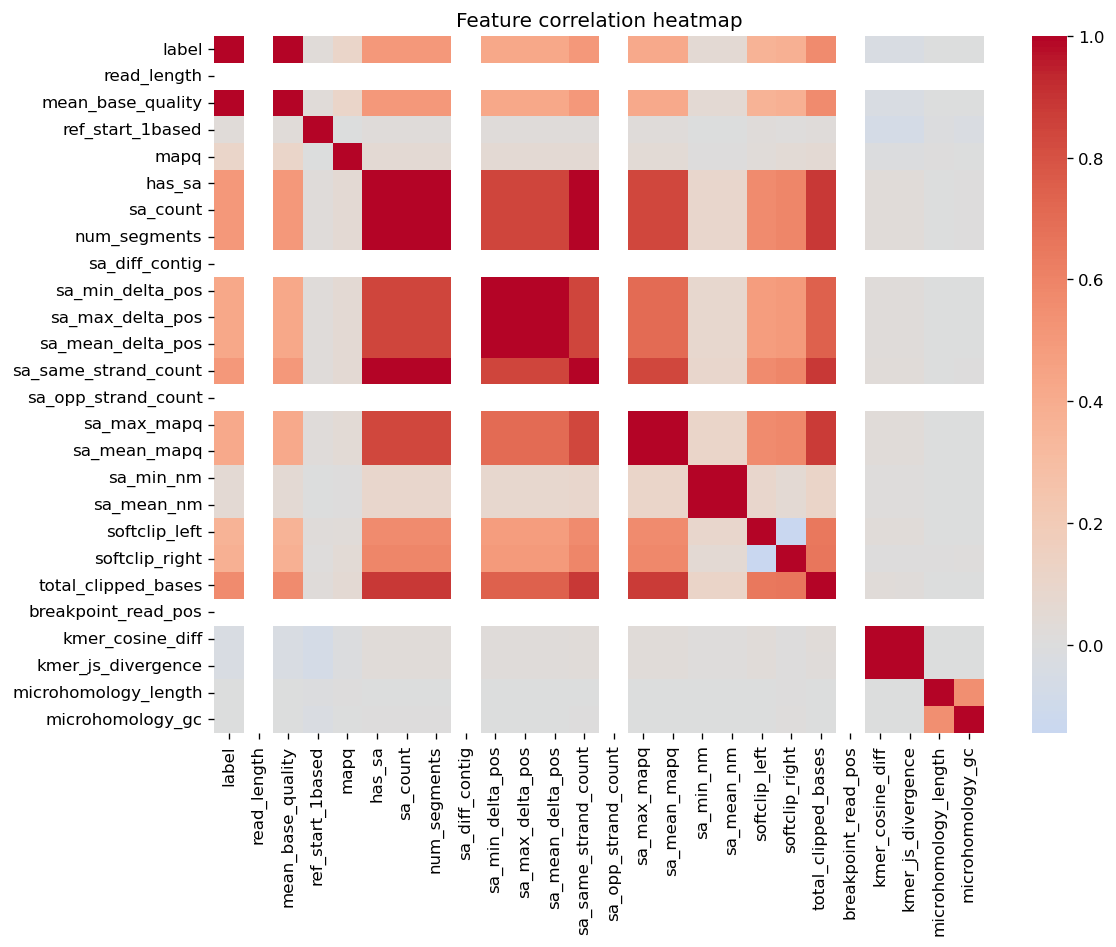

In [8]:
numeric_df = df.select_dtypes(include=["number"])
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [9]:
df.groupby("label").mean(numeric_only=True).T.sort_values(by=0, ascending=False)

label,0,1
ref_start_1based,8200.120953,8428.634600
read_length,150.000000,150.000000
breakpoint_read_pos,75.000000,75.000000
mapq,59.663464,59.987000
mean_base_quality,13.000000,40.000000
num_segments,1.000000,1.405850
kmer_cosine_diff,0.975813,0.974302
kmer_js_divergence,0.975804,0.974322
microhomology_length,0.461742,0.458400
total_clipped_bases,0.437472,25.441750


In [10]:
df2 = df.copy()
df2["class"] = df2["label"].map({0: "clean", 1: "chimeric"})

numeric_cols = df2.select_dtypes(include=["number"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "label"]

rows = []
for feat in numeric_cols:
    for cls_name, group in df2.groupby("class"):
        s = group[feat]
        rows.append(
            {
                "feature": feat,
                "class": cls_name,
                "mean": s.mean(),
                "std": s.std(),
                "median": s.median(),
                "q1": s.quantile(0.25),
                "q3": s.quantile(0.75),
                "iqr": s.quantile(0.75) - s.quantile(0.25),
                "min": s.min(),
                "max": s.max(),
                "n": s.count(),
            }
        )

summary_stats = pd.DataFrame(rows).sort_values(["feature", "class"])
summary_stats.head()

,feature,class,mean,std,median,q1,q3,iqr,min,max,n
40,breakpoint_read_pos,chimeric,75.000000,0.000000,75.000000,75.000000,75.0,0.000000,75.000000,75.0,20000
41,breakpoint_read_pos,clean,75.000000,0.000000,75.000000,75.000000,75.0,0.000000,75.000000,75.0,19983
8,has_sa,chimeric,0.405850,0.491068,0.000000,0.000000,1.0,1.000000,0.000000,1.0,20000
9,has_sa,clean,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,19983
42,kmer_cosine_diff,chimeric,0.974302,0.025729,0.985714,0.958333,1.0,0.041667,0.816883,1.0,20000


In [11]:
out_dir = Path("../results")
out_dir.mkdir(parents=True, exist_ok=True)

summary_path = out_dir / "feature_summary_by_class_PAIR.tsv"
summary_stats.to_csv(summary_path, sep="\t", index=False)

print("Saved:", summary_path.resolve())

Saved: /Users/yvonnelin/Desktop/mitochime/results/feature_summary_by_class_PAIR.tsv


In [12]:
df3 = df.copy()
df3["class"] = df3["label"].map({0: "clean", 1: "chimeric"})

numeric_cols = [
    c for c in df3.columns
    if c not in ["label", "class"] and pd.api.types.is_numeric_dtype(df3[c])
]

print("Number of numeric features:", len(numeric_cols))
print("Example features:", numeric_cols[:10])

os.makedirs("figures/boxplots_PAIR", exist_ok=True)

for feat in numeric_cols:
    plt.figure(figsize=(5, 4))
    sns.boxplot(
        data=df3,
        x="class",
        y=feat,
        showfliers=True,
    )
    plt.xlabel("Class")
    plt.ylabel(feat)
    plt.title(f"{feat} by class (boxplot)")
    plt.tight_layout()
    plt.savefig(f"figures/boxplots_PAIR/box_{feat}.png", dpi=300, bbox_inches="tight")
    plt.close()

print("Saved boxplots to figures/boxplots_PAIR/")

Number of numeric features: 25
Example features: ['read_length', 'mean_base_quality', 'ref_start_1based', 'mapq', 'has_sa', 'sa_count', 'num_segments', 'sa_diff_contig', 'sa_min_delta_pos', 'sa_max_delta_pos']
Saved boxplots to figures/boxplots_PAIR/
